[*********************100%***********************]  1 of 1 completed

Annualized Historical Volatility: Ticker
SPY    0.164785
dtype: float64


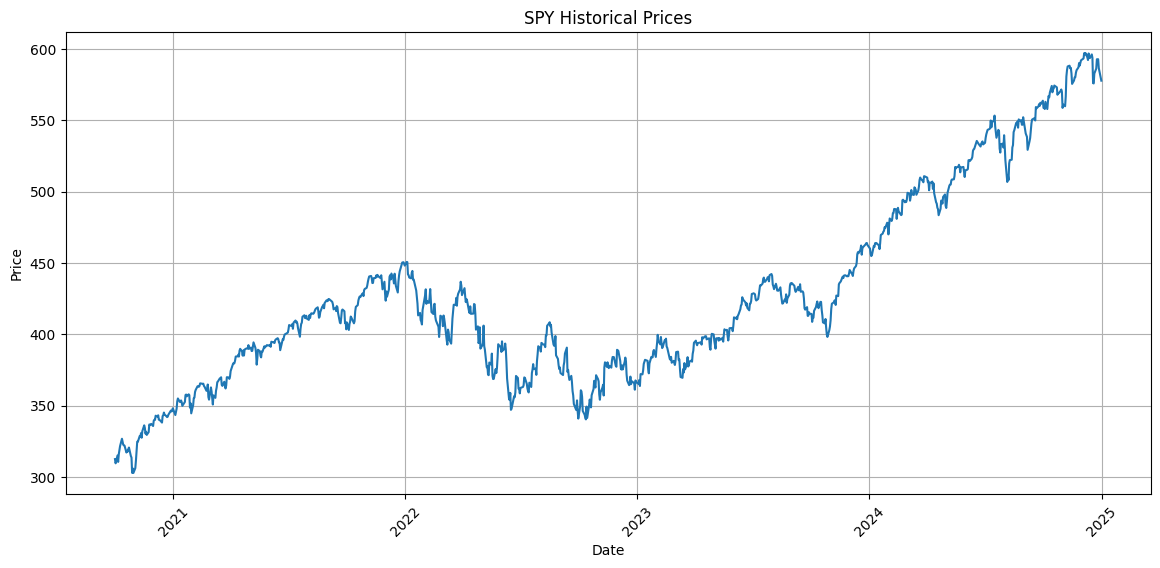

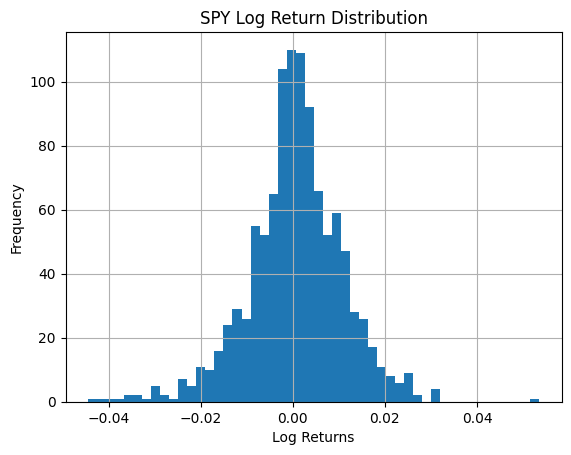

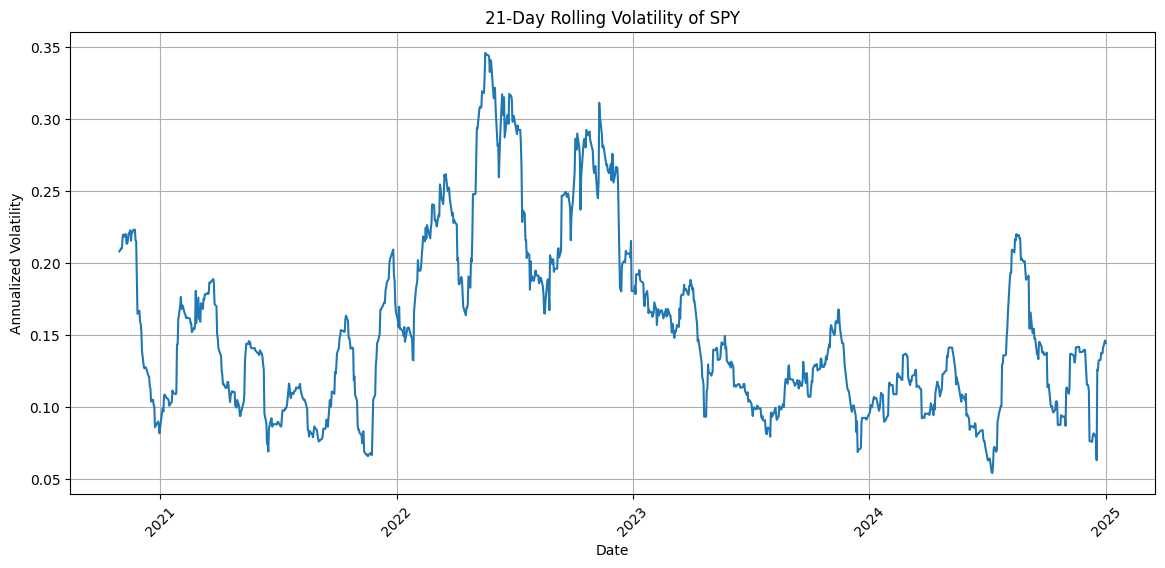

In [5]:
# -- Analyze Historic Volatility Using Real SPY Data

# Import 
import sys
import os

sys.path.append(os.path.abspath(".."))

import yfinance as yf 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from src.volatility import historical_volatility

# Get SPY Data
spy = yf.download(
    "SPY",
    start="2020-10-01",
    end="2025-01-01"
)

spy.head()

# Compute Log Returns 
returns = np.log(spy["Close"]/spy["Close"].shift(1))
returns = returns.dropna()

# Compute Historical Volatility
vol = historical_volatility(spy["Close"])
print("Annualized Historical Volatility:", vol)

# Graph SPY Prices
plt.figure(figsize=(14,6))
plt.plot(spy["Close"])

ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

plt.xticks(rotation=45)

plt.title("SPY Historical Prices")
plt.xlabel("Date")
plt.ylabel("Price")

plt.grid(True)
plt.show()

# Graph Return Distribution 
plt.hist(returns, bins=50)

plt.title("SPY Log Return Distribution")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")

plt.grid(True)
plt.show()

# Graph Rolling Volatility
rolling_vol = (returns.rolling(window=21).std() * np.sqrt(252))

plt.figure(figsize=(14,6))
plt.plot(rolling_vol)
ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%Y')
)

plt.xticks(rotation=45)

plt.title("21-Day Rolling Volatility of SPY")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.grid(True)
plt.show()
